In [166]:
import numpy as np
import pandas as pd

homicide_rates = pd.read_csv("../data/raw/homicide-rate-unodc.csv")
hdi = pd.read_csv("../data/raw/human-development-index.csv")
gini_index = pd.read_csv("../data/raw/economic-inequality-gini-index.csv")
urbanization = pd.read_csv("../data/raw/share-of-population-urban.csv")
gdp_per_capita = pd.read_csv("../data/raw/gdp-per-capita-maddison-project-database.csv")
rule_of_law = pd.read_csv("../data/raw/rule-of-law-index.csv")
corruption = pd.read_csv("../data/raw/political-corruption-index.csv")

In [167]:
homicide_rates.head()

,Entity,Code,Year,"Homicide rate per 100,000 population",World region according to OWID
0,Afghanistan,AFG,2009,4.059550,Asia
1,Afghanistan,AFG,2010,3.475452,Asia
2,Afghanistan,AFG,2011,4.194535,Asia
3,Afghanistan,AFG,2012,6.374339,Asia
4,Afghanistan,AFG,2015,9.952186,Asia


In [168]:
homicide_rates_new = homicide_rates.rename(columns={"Homicide rate per 100,000 population": "homicide-rate-100000"})

In [169]:
homicide_rates_new.head()

,Entity,Code,Year,homicide-rate-100000,World region according to OWID
0,Afghanistan,AFG,2009,4.059550,Asia
1,Afghanistan,AFG,2010,3.475452,Asia
2,Afghanistan,AFG,2011,4.194535,Asia
3,Afghanistan,AFG,2012,6.374339,Asia
4,Afghanistan,AFG,2015,9.952186,Asia


In [170]:
hdi.head()

,Entity,Code,Year,Human Development Index,World region according to OWID
0,Afghanistan,AFG,1990,0.285,Asia
1,Afghanistan,AFG,1991,0.291,Asia
2,Afghanistan,AFG,1992,0.301,Asia
3,Afghanistan,AFG,1993,0.311,Asia
4,Afghanistan,AFG,1994,0.305,Asia


In [171]:
# Transform all the columns in the dataframes to lowercase

hdi_new = hdi.rename(columns={"Human Development Index": "hdi"})
def to_lower_columns(df: pd.DataFrame):
    df.columns = [col.lower() for col in df.columns]

gdp_per_capita_new = gdp_per_capita.copy()
gini_index_new = gini_index.copy()
urban_copy = urbanization.copy()
corruption_new = corruption.copy()
rule_of_law_new = rule_of_law.copy()

df_list = [homicide_rates_new, hdi_new, gdp_per_capita_new, gini_index_new, urban_copy, rule_of_law_new, corruption_new]
[to_lower_columns(df) for df in df_list]

[None, None, None, None, None, None, None]

In [172]:
hdi_new.head()
homicide_rates_new.head()
corruption_new.head()

,entity,code,year,political corruption index,world region according to owid
0,Afghanistan,AFG,1789,0.418,Asia
1,Afghanistan,AFG,1790,0.418,Asia
2,Afghanistan,AFG,1791,0.418,Asia
3,Afghanistan,AFG,1792,0.418,Asia
4,Afghanistan,AFG,1793,0.418,Asia


In [173]:
from typing import List

def merge_datasets(datasets: List[pd.DataFrame]) -> pd.DataFrame:
    master_df = datasets[0]
    for i in range(1, len(datasets)):
        master_df = master_df.merge(datasets[i], how='inner')

    return master_df

df = merge_datasets(df_list)

In [174]:
df.head()
df = df.drop(['world region according to owid', 'gdp per capita (annotations)'], axis=1)

In [175]:
# We can see that we have no missing values, so we won't need to handle them

df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1469 entries, 0 to 1468
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   entity                                    1469 non-null   str    
 1   code                                      1469 non-null   str    
 2   year                                      1469 non-null   int64  
 3   homicide-rate-100000                      1469 non-null   float64
 4   hdi                                       1469 non-null   float64
 5   gdp per capita                            1469 non-null   float64
 6   gini coefficient                          1469 non-null   float64
 7   urban population (% of total population)  1469 non-null   float64
 8   rule of law index                         1469 non-null   float64
 9   political corruption index                1469 non-null   float64
dtypes: float64(7), int64(1), str(2)
memory usage: 1

In [176]:
df.columns = df.columns.str.replace(' ', '-')
df = df.rename(columns={'urban-population-(%-of-total-population)': 'urbanization'})
df.head()

,entity,code,year,homicide-rate-100000,hdi,gdp-per-capita,gini-coefficient,urbanization,rule-of-law-index,political-corruption-index
0,Albania,ALB,1996,8.380375,0.647,3965.6853,0.270103,38.899605,0.496,0.682
1,Albania,ALB,2002,6.891948,0.697,5608.9624,0.317390,43.152042,0.515,0.744
2,Albania,ALB,2005,5.006243,0.723,6858.4673,0.305957,45.993767,0.542,0.722
3,Albania,ALB,2008,3.107322,0.749,8522.1300,0.299847,49.385070,0.516,0.757
4,Albania,ALB,2012,5.395182,0.790,9634.3340,0.289605,53.863754,0.525,0.766


In [177]:
# Analyzing the merged dataset
    # 1469 rows, 10 columns -> migth be insufficient, we'll assess this when validating the model
    # No missing values -> good
    # No duplicates -> good

df.duplicated().sum()
df[df.duplicated()]

duplicated_key = df.duplicated(subset=['code', 'year'], keep=False)
df[duplicated_key].sort_values(by=['code', 'year'])

,entity,code,year,homicide-rate-100000,hdi,gdp-per-capita,gini-coefficient,urbanization,rule-of-law-index,political-corruption-index


In [178]:
# Analyzing the target / label

duplicated_rate = df.duplicated(subset=['homicide-rate-100000']).sum()
duplicated_rate

mask = df['homicide-rate-100000'].duplicated(keep=False)
dupl = df.loc[mask, ['entity', 'code', 'year', 'homicide-rate-100000']]
dupl

# We can see that 3 countries had/have equal homicide rates of 0

,entity,code,year,homicide-rate-100000
616,Iceland,ISL,2006,0.0
618,Iceland,ISL,2008,0.0
819,Luxembourg,LUX,2012,0.0
843,Malta,MLT,2006,0.0


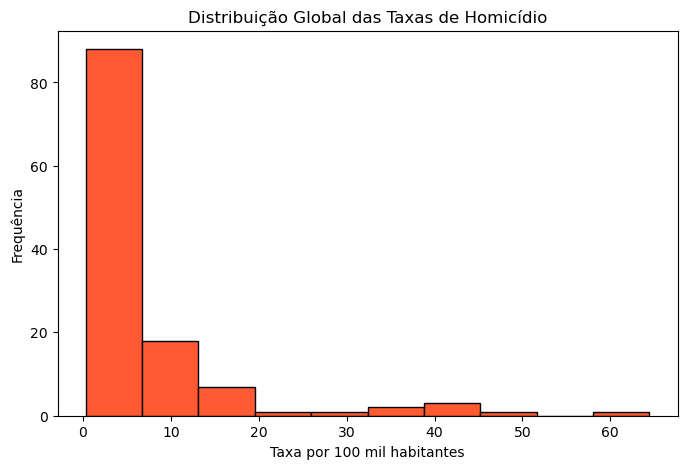

entity
El Salvador    64.440786
Honduras       47.282874
Lesotho        43.211960
Colombia       42.018797
Jamaica        38.945825
                 ...    
South Korea     0.717107
Switzerland     0.679545
Iceland         0.511060
Qatar           0.443343
Japan           0.317319
Name: homicide-rate-100000, Length: 122, dtype: float64

In [179]:
import matplotlib.pyplot as plt

dataX = df.groupby('entity')['homicide-rate-100000'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
plt.hist(dataX, color='#ff5a32', edgecolor='black')

plt.title('Distribuição Global das Taxas de Homicídio')
plt.xlabel('Taxa por 100 mil habitantes')
plt.ylabel('Frequência')
plt.show() # we can see that most countries have a mean homicide rate between 0 and 10

dataX # we can see that from the top 5 most violent countries, 4 are from latin america and 1 from africa

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'homicide-rate-100000'}>,
        <Axes: title={'center': 'hdi'}>],
       [<Axes: title={'center': 'gdp-per-capita'}>,
        <Axes: title={'center': 'gini-coefficient'}>,
        <Axes: title={'center': 'urbanization'}>],
       [<Axes: title={'center': 'rule-of-law-index'}>,
        <Axes: title={'center': 'political-corruption-index'}>, <Axes: >]],
      dtype=object)

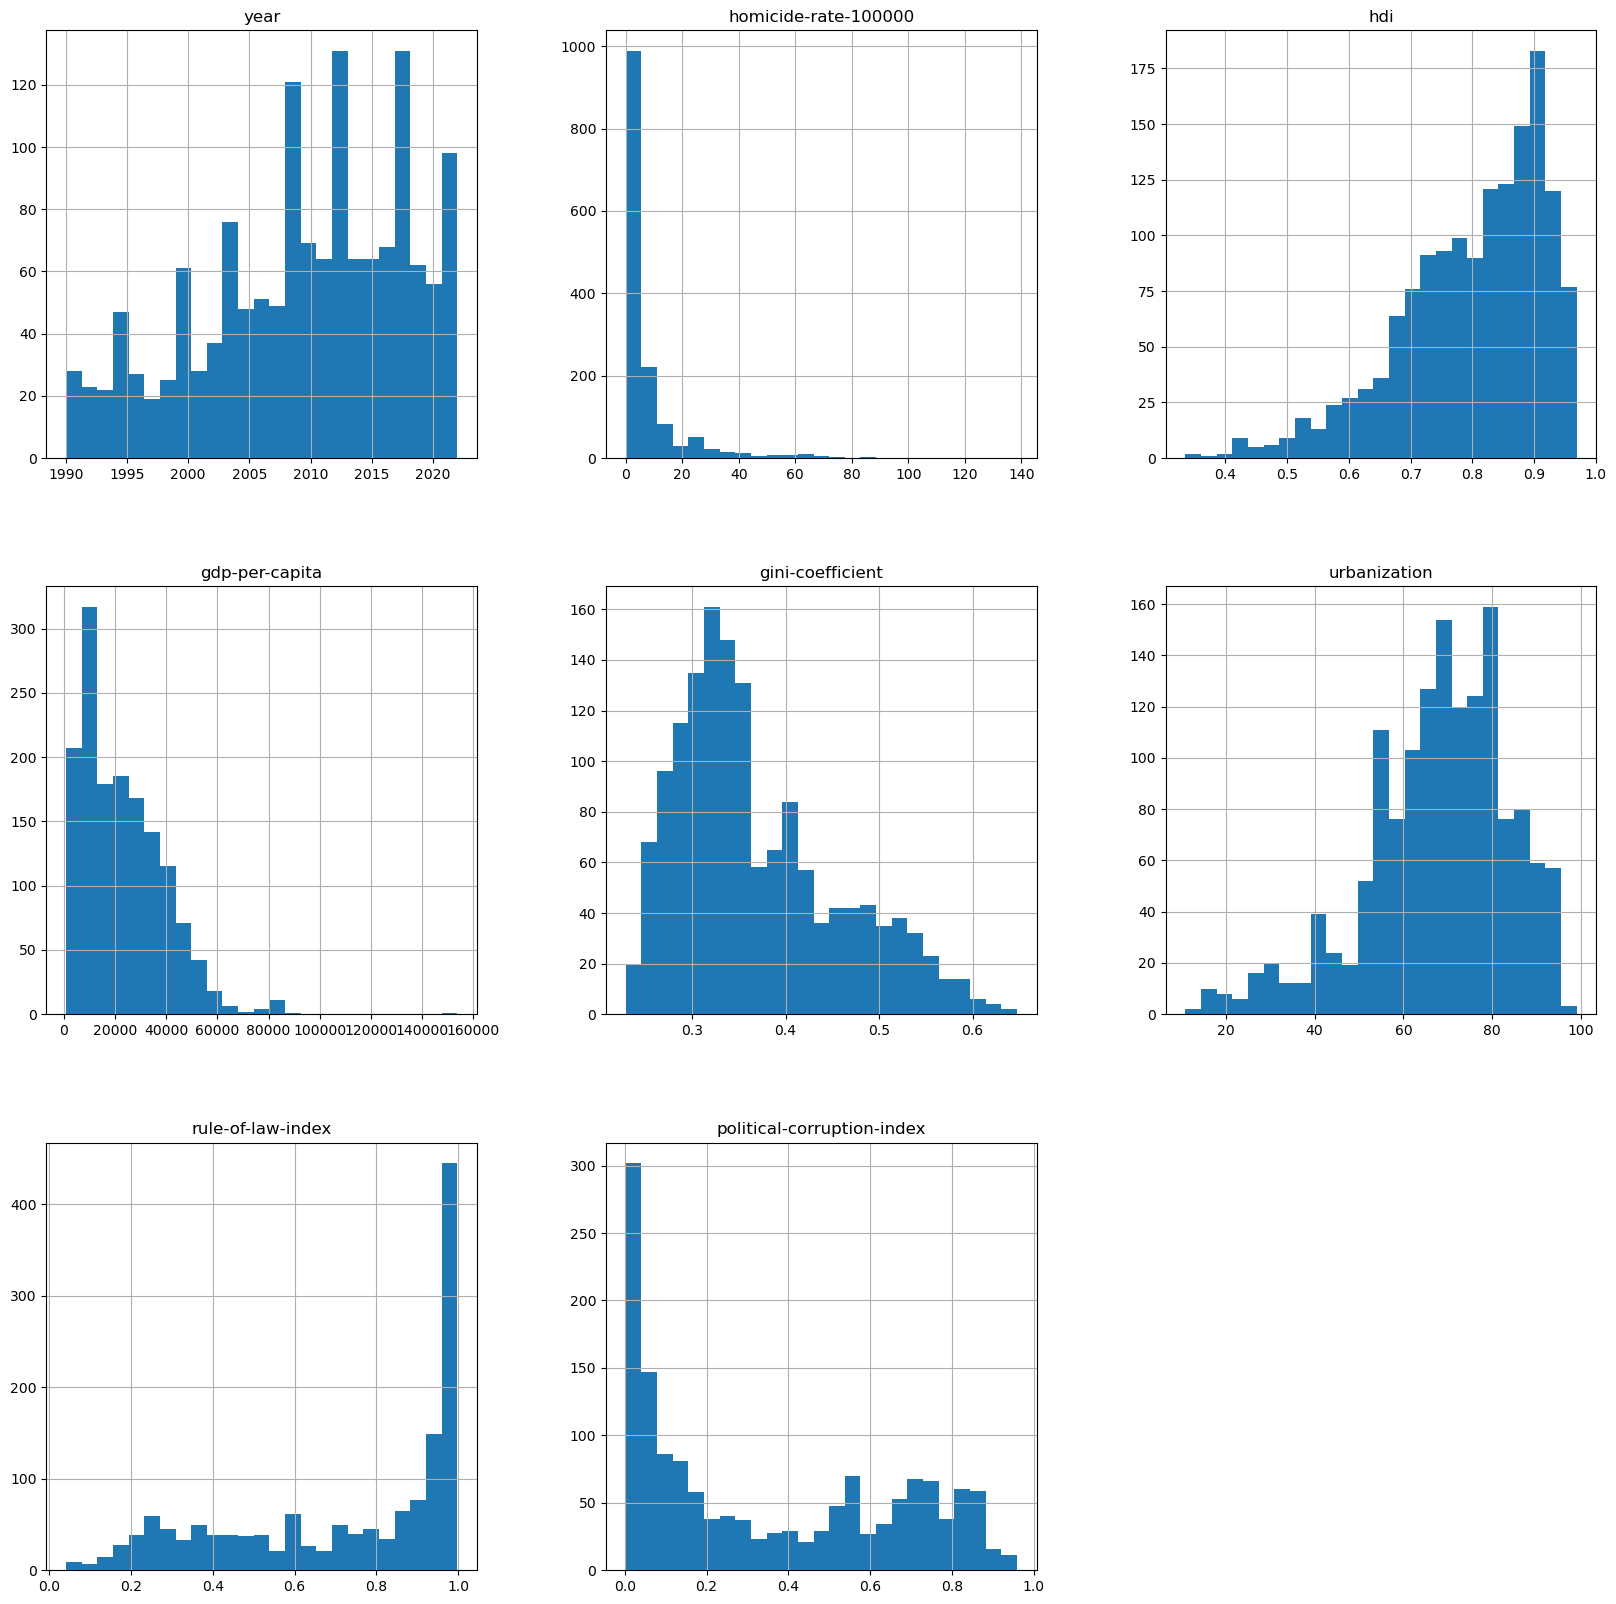

In [180]:

df.hist(figsize=(20, 20), bins=25)

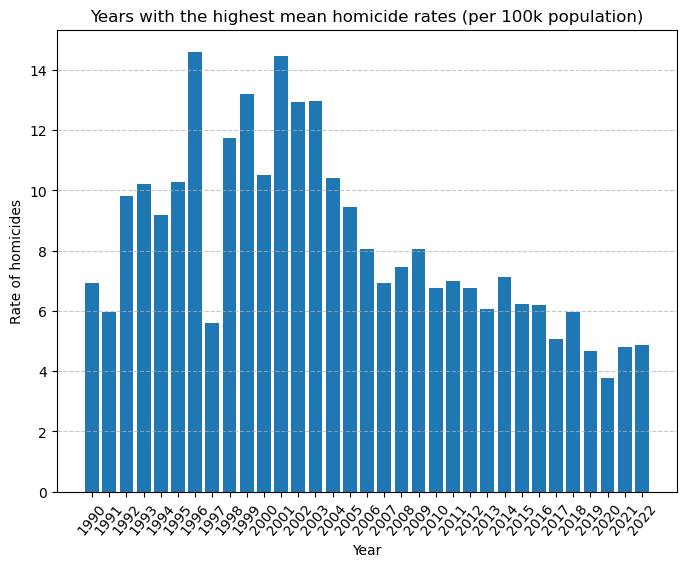

In [204]:
year_total = df.groupby('year')['homicide-rate-100000'].mean().reset_index(
    name='Total Rate of Homicides').sort_values(ascending=True, by='year').round(2)

plt.figure(figsize=(8, 6))
plt.bar(year_total['year'].astype(str), year_total['Total Rate of Homicides'])
plt.title("Years with the highest mean homicide rates (per 100k population)")
plt.xlabel('Year')
plt.ylabel('Rate of homicides')
plt.xticks(rotation=50)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show() # shows the years with the highest homicide rates

# year_total

KeyError: 0

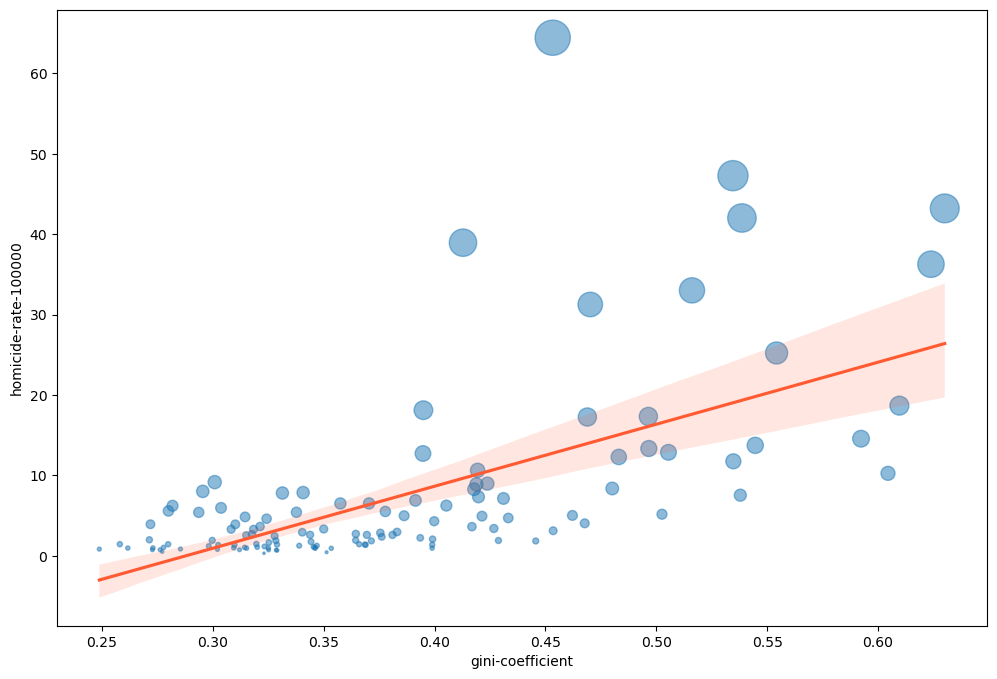

In [264]:

import seaborn as sns

df_country = df.groupby('entity').agg({
    'gini-coefficient': 'mean',
    'homicide-rate-100000': 'mean'
}).reset_index()

plt.figure(figsize=(12, 8))
sns.regplot(data=df_country, x='gini-coefficient', y='homicide-rate-100000',
            scatter_kws={'alpha': 0.5, 's':df_country['homicide-rate-100000'] * 10}, line_kws={'color': '#ff5a32'})

for i in range(df_country[0]):
    plt.text(df_country['gini-coefficient'][i],
                 df_country['homicide-rate-100000'][i],
                 df_country['entity'][i], fontsize=9)

plt.show()

#df.plot(kind='scatter', x='gini-coefficient', y='homicide-rate-100000', alpha=0.7,
        # label='Homicide per Country',
        # c='homicide-rate-100000',
        # s='homicide-rate-100000')

<Axes: xlabel='gdp-per-capita', ylabel='homicide-rate-100000'>

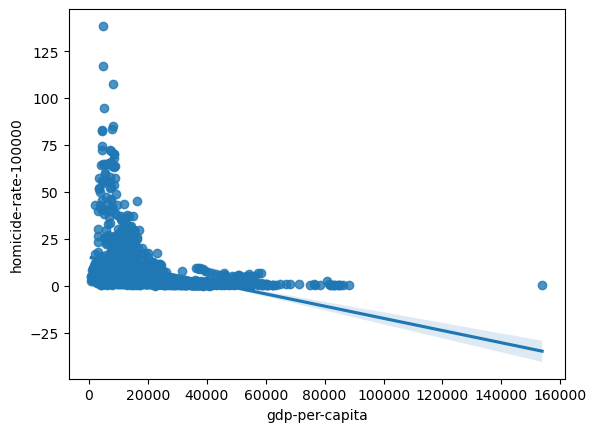

In [267]:
sns.regplot(x="gdp-per-capita", y="homicide-rate-100000", data=df)

In [273]:
corr_test = df.drop(['entity', 'code', 'year'], axis=1)
corr = corr_test.corr()
corr

,homicide-rate-100000,hdi,gdp-per-capita,gini-coefficient,urbanization,rule-of-law-index,political-corruption-index
homicide-rate-100000,1.000000,-0.458280,-0.385717,0.587211,-0.105664,-0.344768,0.391951
hdi,-0.458280,1.000000,0.814195,-0.537414,0.678724,0.709144,-0.758772
gdp-per-capita,-0.385717,0.814195,1.000000,-0.473172,0.575449,0.666550,-0.735285
gini-coefficient,0.587211,-0.537414,-0.473172,1.000000,-0.120867,-0.326282,0.422790
urbanization,-0.105664,0.678724,0.575449,-0.120867,1.000000,0.493970,-0.529953
rule-of-law-index,-0.344768,0.709144,0.666550,-0.326282,0.493970,1.000000,-0.937930
political-corruption-index,0.391951,-0.758772,-0.735285,0.422790,-0.529953,-0.937930,1.000000
